<a href="https://colab.research.google.com/github/aic309/test-ai-assignment-/blob/main/Alaric_AI_Searching_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center> <h1> Search Agents </h1> </center>

> *This homework is adapted from Assignment 2 of 601.664 Artificial Intelligence course for Spring 2026 at Johns Hopkins University*

In this homework, you will implement a search agent.

More specifically, you will:
1. Implement breadth-first search algorithm.
2. Implement a second search algorithm of your choice.
3. Apply these algorithms to find a path on a map between two points.

<center> <h2> General Instructions </h2> </center>

1. Press __File > Save a copy in Drive...__ tab. This will allow you to have your own copy and change it.
2. Follow all the steps in this collaboratory file and write/change/uncomment code as necessary.
3. Do not forget to occasionally press __File > Save__ tab to save your progress.
4. Once you get your results, write a report to compare both algorithms (minimum 3 pages, maximum 5 pages).
5. Attach your Google Colab file alongside your report in the Google Classroom submission.

<center> <h2> Installing dependencies </h2> </center>

Download the map object containing a graph representation of the UGM campus (`ugm_campus_graph.graph`),
as well as the python library (`ai_search_lib.py`) that provides the `Node` class,
plotting/visualization helpers, and a graph-inspection helper you'll use in this homework.

Be careful, if you leave your notebook without use for a long time, all the downloaded and installed libraries will be lost and you will have to repeat the download again.


In [13]:
!gdown 1z1xsIffeyt3Z9r2qJeHolKsDGmJgzQqu -O ugm_campus_graph.graph


Downloading...
From: https://drive.google.com/uc?id=1z1xsIffeyt3Z9r2qJeHolKsDGmJgzQqu
To: /content/ugm_campus_graph.graph
100% 256k/256k [00:00<00:00, 84.4MB/s]


In [14]:
!gdown 1j3Q0xJmOIGAkZK61vcX4041idGsLT0Lc -O ai_search_lib.py

Downloading...
From (original): https://drive.google.com/uc?id=1j3Q0xJmOIGAkZK61vcX4041idGsLT0Lc
From (redirected): https://drive.google.com/uc?id=1j3Q0xJmOIGAkZK61vcX4041idGsLT0Lc&confirm=t&uuid=1de46110-c8e8-4025-9ed8-0457b1864cc5
To: /content/ai_search_lib.py
100% 18.8k/18.8k [00:00<00:00, 45.3MB/s]


In [15]:
pip install networkx matplotlib

<center> <h2> Map Graph </h2> </center>

Our map is represented as a graph object. We are using the networkx library for that.
It is not necessary to be able to use the library, but we refer those who are interested to the following tutorial:

https://networkx.github.io/documentation/stable/tutorial.html

This graph was built from real OpenStreetMap data for the UGM campus and its immediate surroundings
in Yogyakarta. This is s a real street network, not a toy example.

Before touching any search algorithm, it's worth actually understanding what you're searching
over: how many nodes/edges there are, whether the graph is directed, what a "weight" on an edge
actually represents, etc. The `inspect_graph` function below prints all of this.


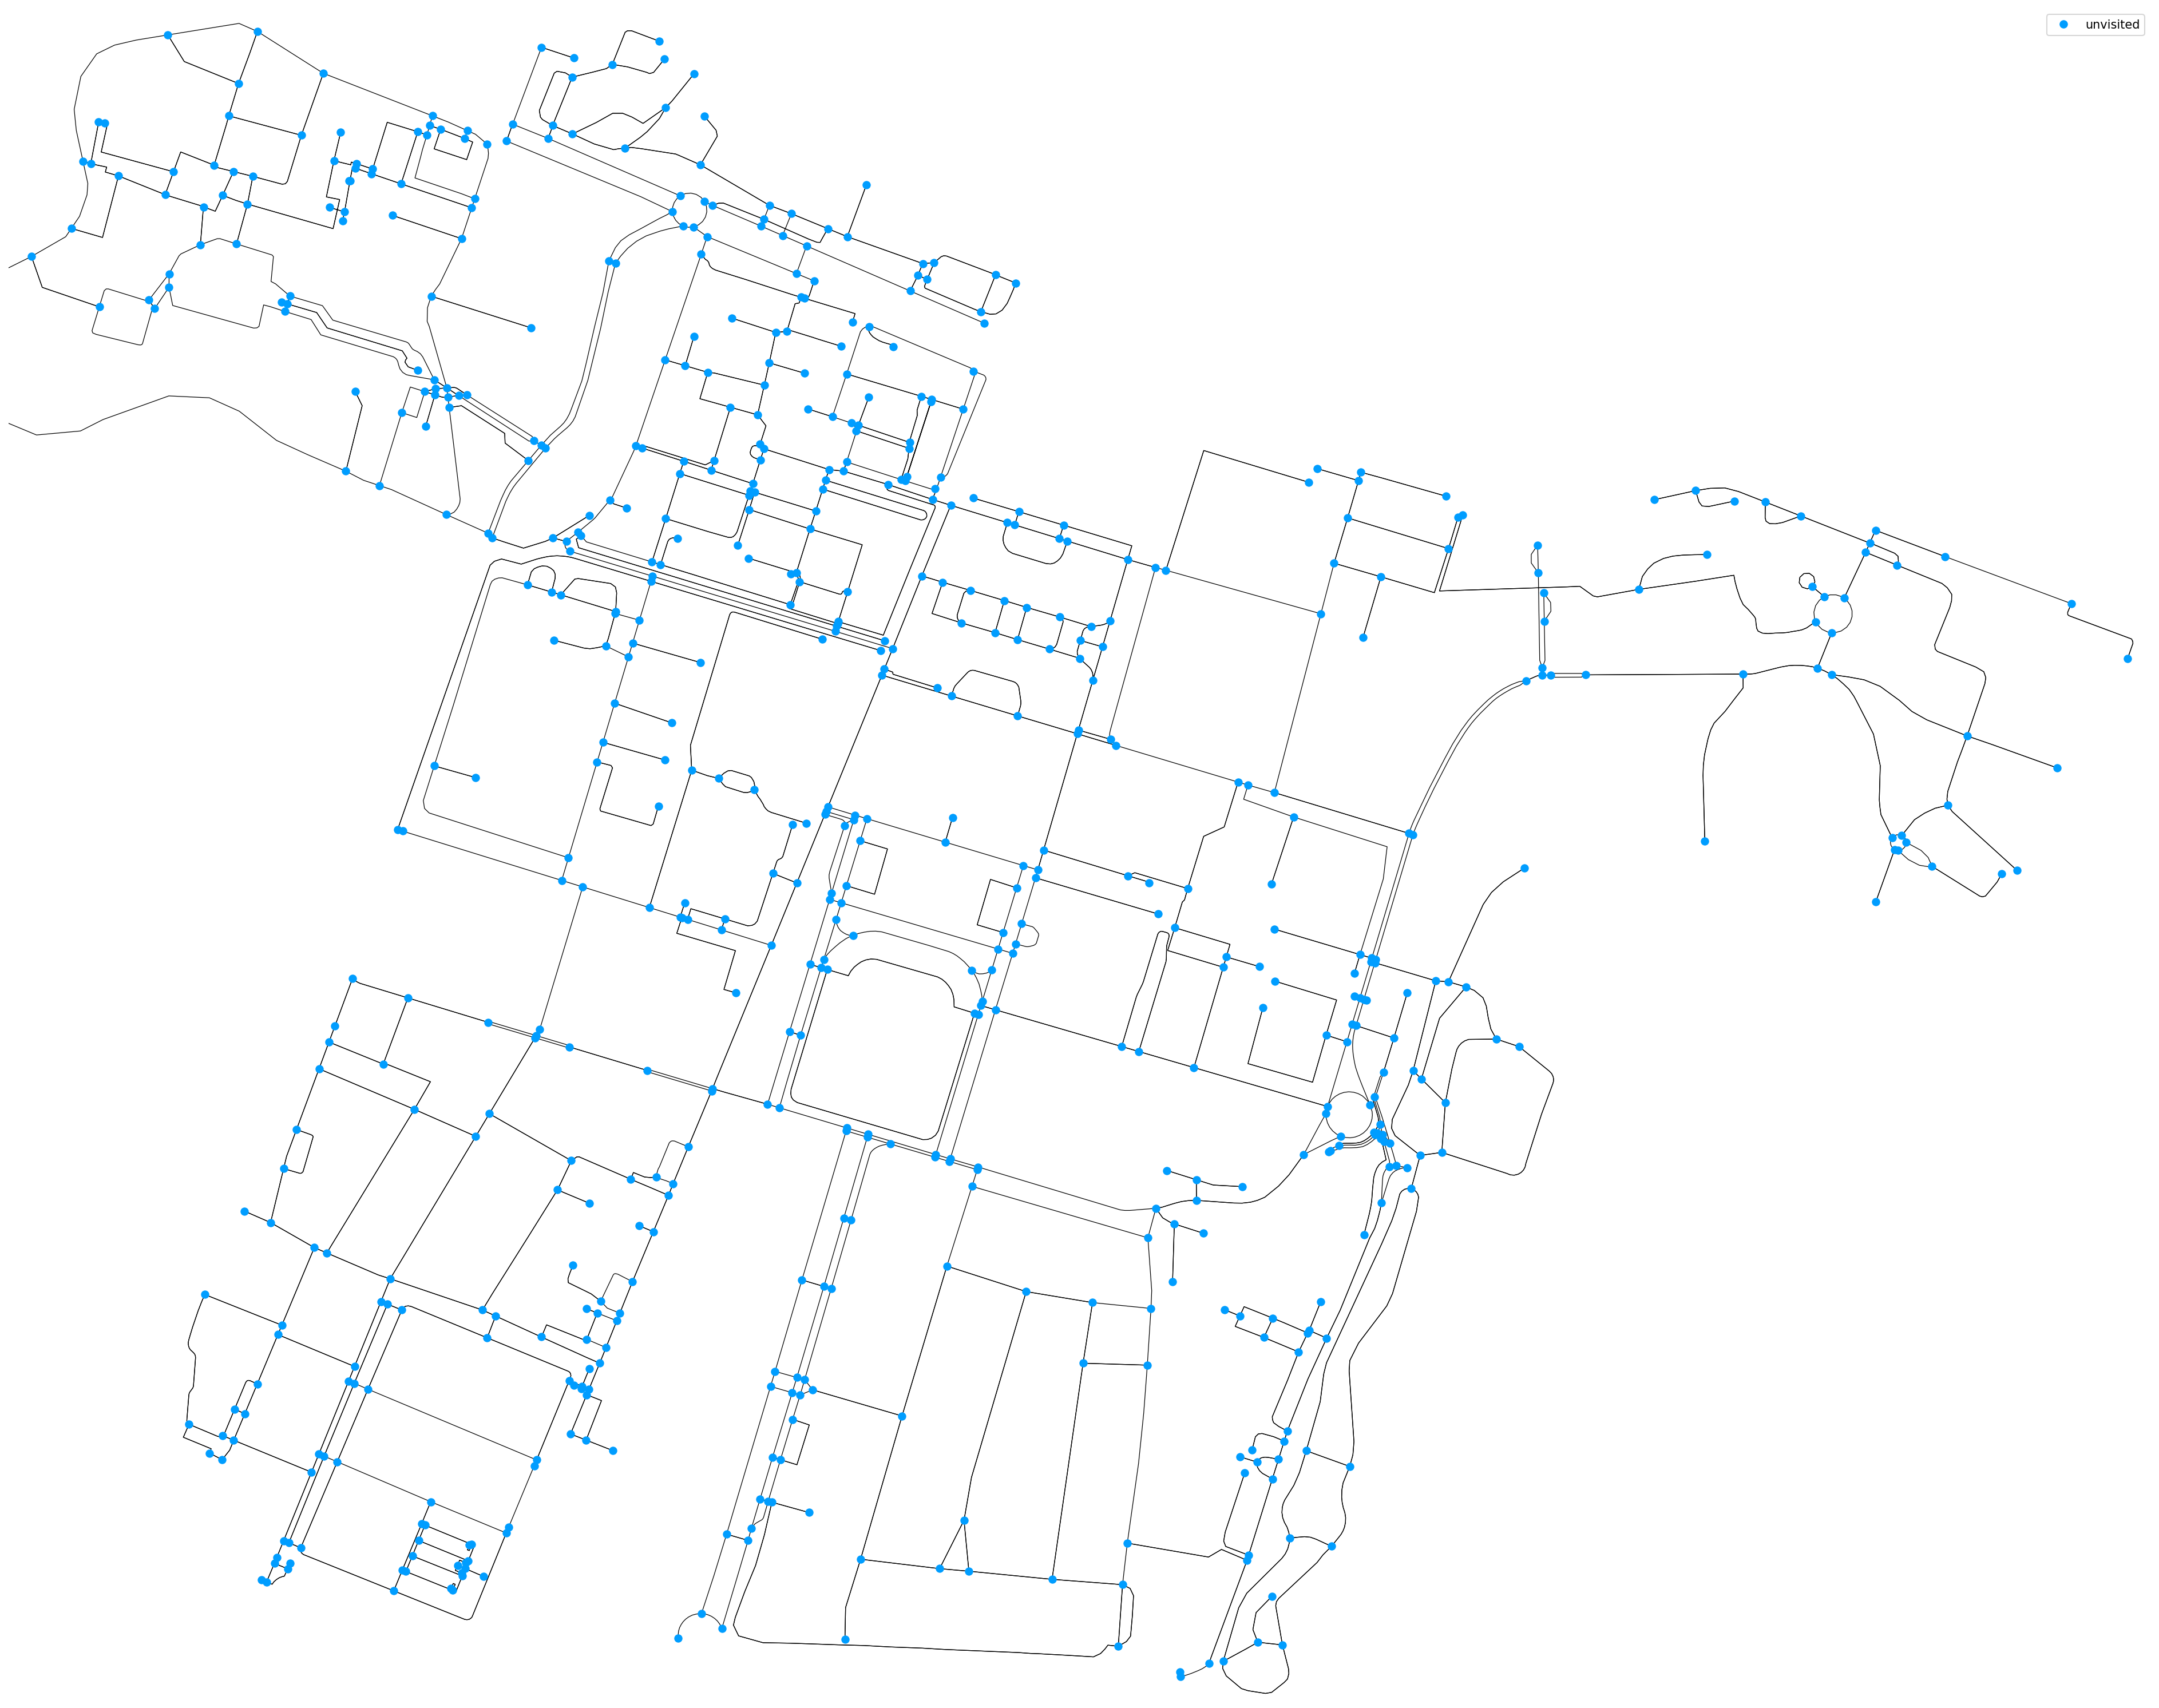

In [16]:
from ai_search_lib import Node, clear_map, plot_graph, plot_graph_route, inspect_graph

import pickle
import networkx as nx


with open('ugm_campus_graph.graph', 'rb') as file:

    graph = pickle.load(file)


plot_graph(graph, fig_height=20, dpi=150, node_size=35)


<center> <h2> Inspecting the graph </h2> </center>

Run the cell below to print full details about the graph: how many nodes/edges it has,
whether it's directed, what attributes each node/edge carries, whether edges have real-world
distances attached (for cost/weight), how many streets are one-way, and a preview
of the raw node/edge data plus adjacency lists.

This is especially important for a **directed** graph like this one. Some streets are one-way,
so `graph.neighbors(node)` will only return nodes reachable by *following* the direction of the
street, not against it. Understanding this now will save you a lot of confusion later when your
search algorithm behaves unexpectedly.


In [17]:
inspect_graph('ugm_campus_graph.graph', node_limit=10, edge_limit=10, adjacency_preview=3)

SUMMARY
Type:            MultiDiGraph
Directed:        True
Multigraph:      True
Nodes:           666
Edges:           1506
CRS:             EPSG:32749
Weakly connected:   True
Strongly connected: False
  -> 14 strongly-connected components, sizes: [641, 10, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  -> giant component covers 641/666 nodes
  -> WARNING: a start/goal pair split across components may have
     NO valid directed path even if one exists the other way.
Degree:          min=1, max=10, avg=4.52
Dead-end nodes (degree 1): 3

ATTRIBUTE SCHEMA
Node attributes: ['highway', 'junction', 'street_count', 'x', 'y']
Edge attributes: ['access', 'bridge', 'geometry', 'highway', 'junction', 'lanes', 'length', 'maxspeed', 'name', 'oneway', 'osmid', 'reversed', 'service', 'tunnel', 'width']

WEIGHT / COST STATS  (using edge attribute: 'length')
Edges with 'length':    1506
Edges MISSING 'length': 0  
Min:  0.851
Max:  546.568
Mean: 47.613
Sum:  71704.686

DIRECTION / ONEWAY STATS
Total directed

<center> <h2> Search Tree </h2> </center>

Search algorithms require a data structure to keep track of the search tree that is being constructed. For each node of the tree, we have a data structure that contains these components:

1. State -- an integer unique ID of the node of the graph (used by networkx to access nodes).
2. Parent -- a node in the search tree that generated this node. This will be useful for constructing the path during search.
3. Path cost --  a cost associated with current node.

This `Node` class (along with `clear_map`) lives in `ugm_search_lib.py` and is imported above.
You can use methods like ```mark_graph_node_as_start``` to mark nodes with a certain color so
that you can see them on the map during visualization. Call ```clear_map``` to remove all marks
placed on the map and restore the map to the default view.

For reference, here is the exact source of the `Node` class you're using (no need to modify it):


In [18]:
import inspect as _pyinspect
print(_pyinspect.getsource(Node))

class Node:
    """A node in a search tree. Contains a pointer to the parent (the node
    that this is a successor of) and to the state for this node
    representing actual graph node (graph node ID)."""

    def __init__(self, state, parent=None, path_cost=0):
        """Create a search tree Node"""
        self.state = state
        self.parent = parent
        self.path_cost = path_cost
        self.depth = 0
        if parent:
            self.depth = parent.depth + 1

    def __repr__(self):
        return "<Node state={}>".format(self.state)

    def expand(self, graph):
        """List the nodes reachable in one step from this node i.e.
        neighbours of the current node. NOTE: the graph is directed,
        so this follows edge direction (one-way streets are respected)."""
        return [self.child_node(graph, state)
                for state in graph.neighbors(self.state)]

    def child_node(self, graph, state):
        """Create a new search node and mark it as a chil

Now let's create the starting and destination nodes. We will try to find a path between them.

As mentioned previously, we use unique IDs representing the graph nodes. If you want to change the
starting and destination nodes you can display the map with IDs displayed near each node and pick
the ones that you want (use the commented out line of code below).

We also mark the starting node and destination node with blue and red color respectively.



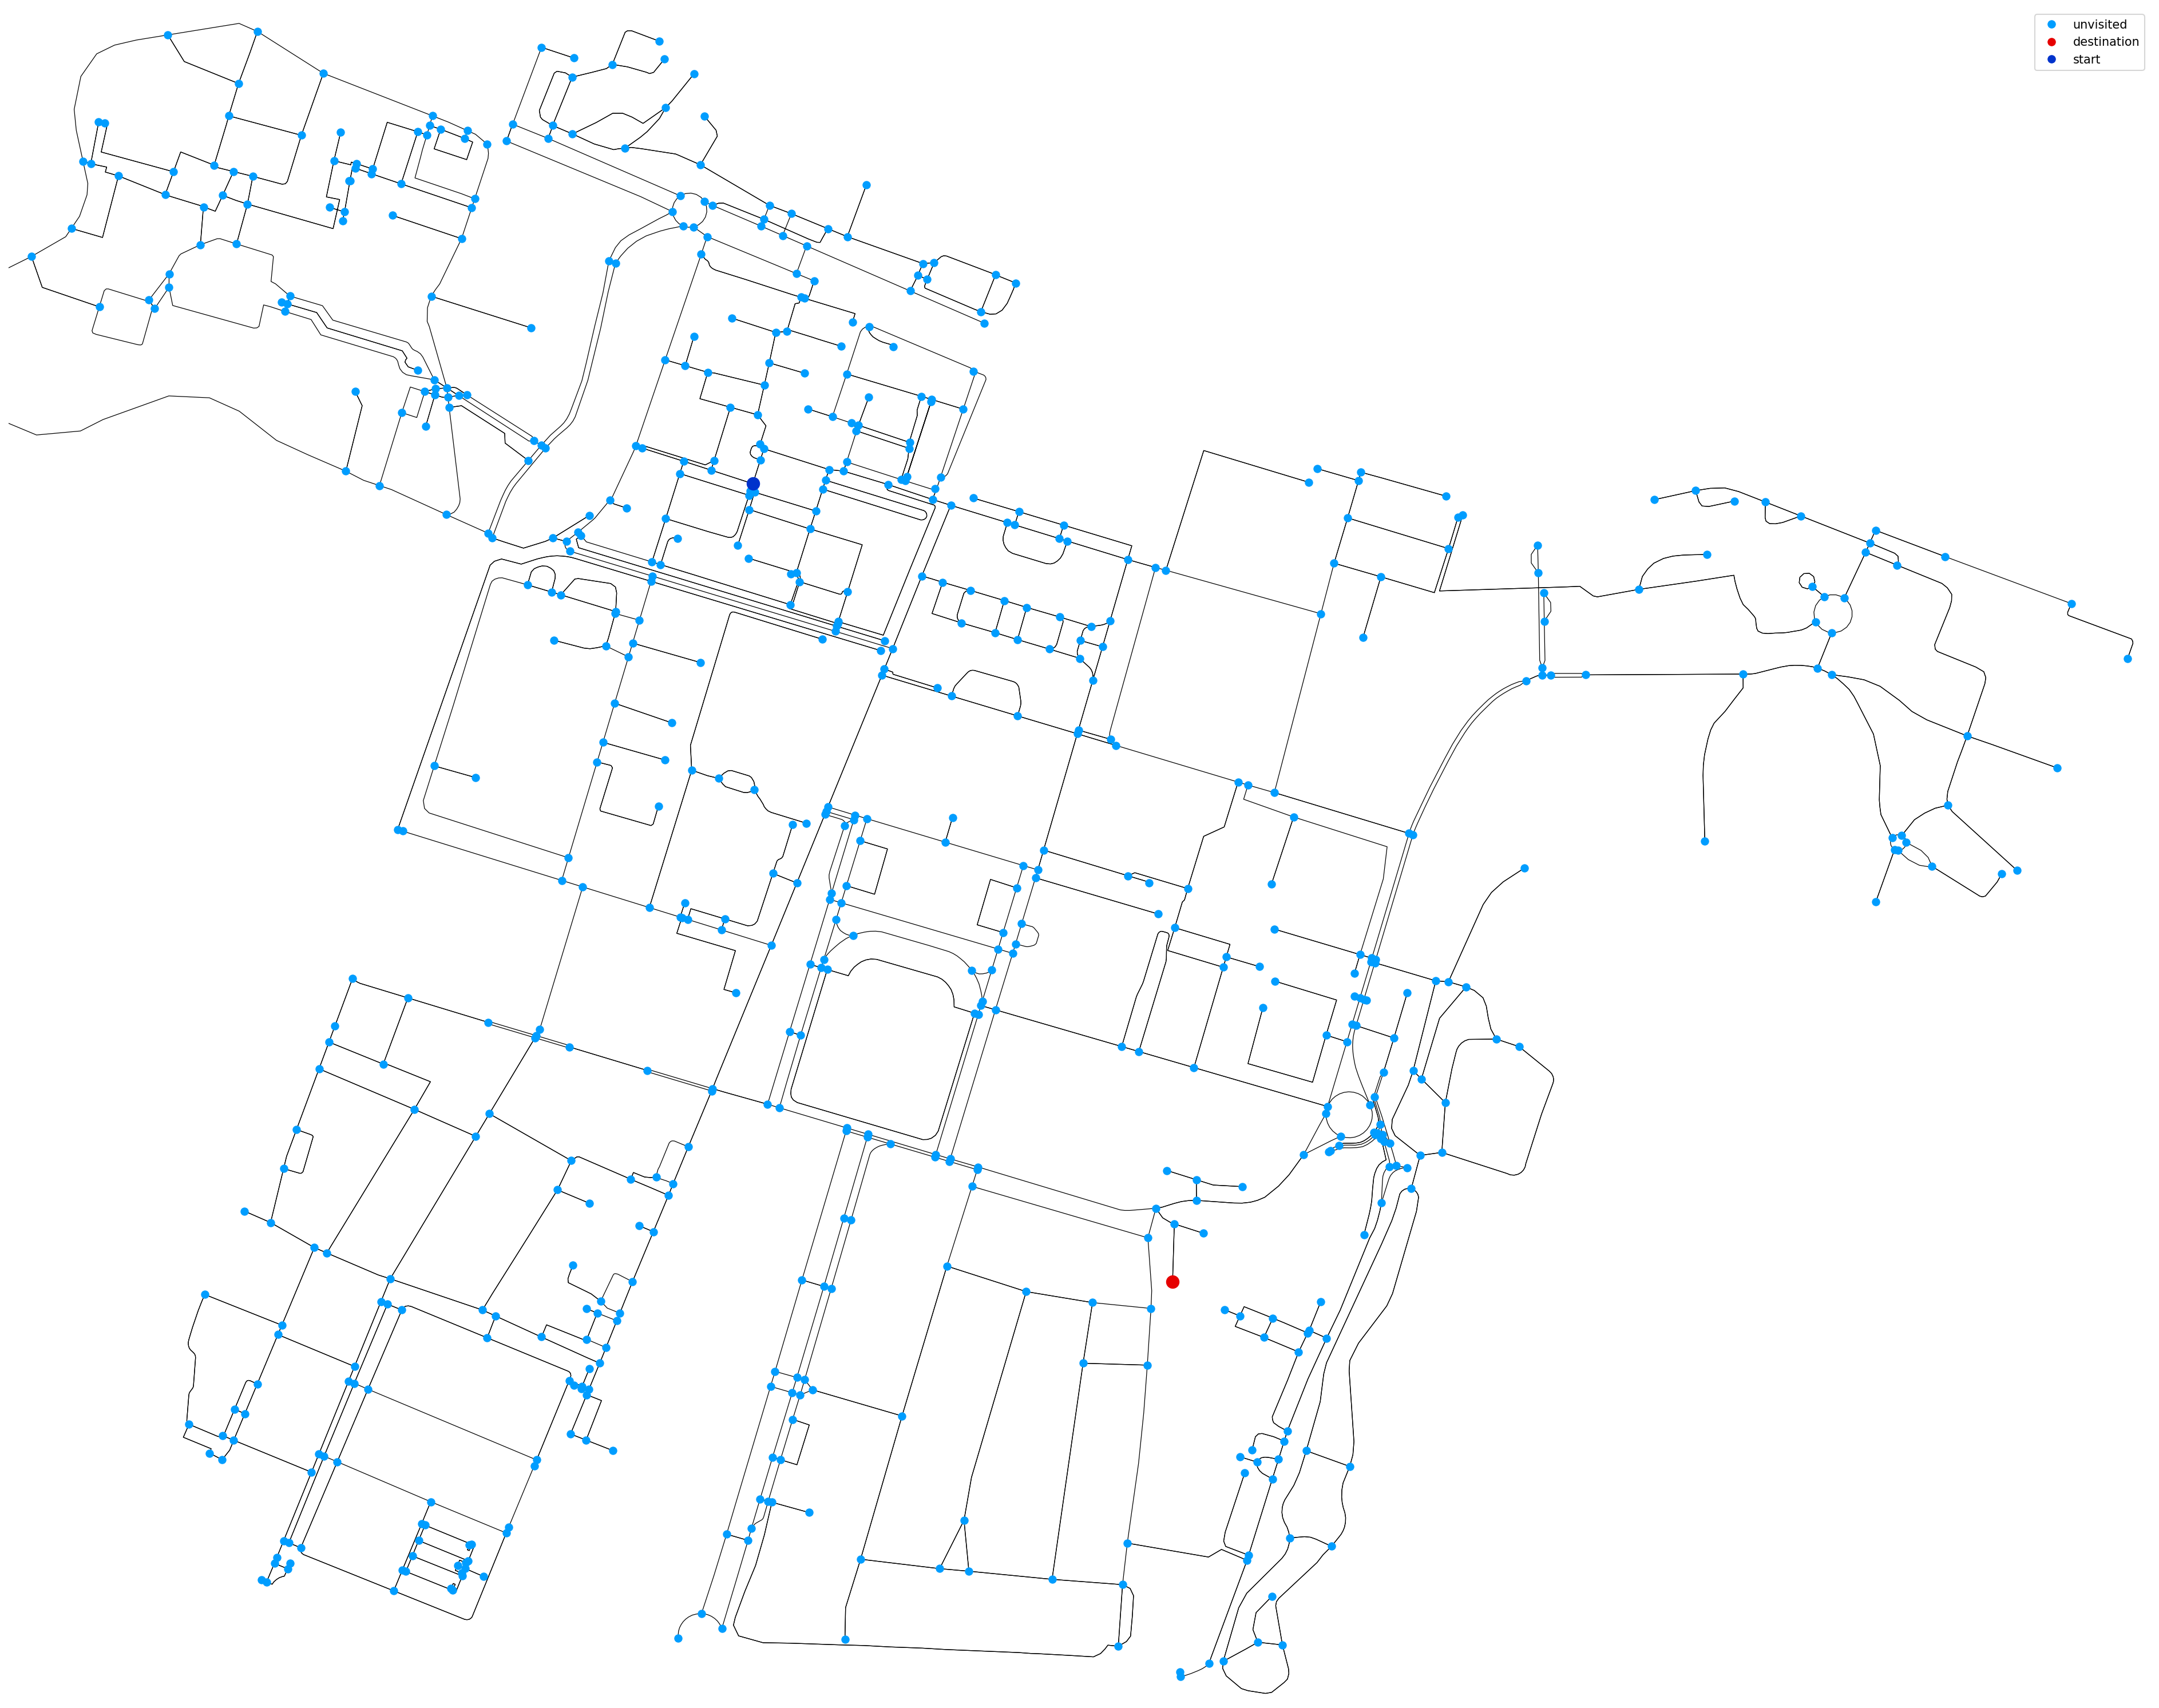

In [19]:
# Pos satpam FMIPA/Facutly of Mathematics & Natural Science security post
start_graph_state = 13823197178

# Masjid Kampus UGM/UGM Campus Mosque
destination_graph_state = 9179685496


start_node = Node(state=start_graph_state)
destination_node = Node(state=destination_graph_state)

start_node.mark_graph_node_as_start(graph)
destination_node.mark_graph_node_as_destination(graph)

plot_graph(graph, fig_height=20, dpi=150, node_size=35)

# Use the function below if you want to change starting node
# and destination one. The function below will display a huge map with
# numbers displayed on top of each node.
#plot_graph(graph, fig_height=100, dpi=200, node_size=35, annotate=True)
# Since the image is huge, you are recommended to save the image
# and open it in your local image editor.

# Use this to clear the map
#clear_map(graph)


You are tasked to implement breadth-first search. Here are some parts of code that will be useful in your implementation.

Here is a pseudocode:
````
1  procedure BFS(G, start_graph_state):
2      let frontier_queue be a queue
3      let explored_set be a set
4      frontier_queue.enqueue(start_graph_state)
5      while frontier_queue is not empty
6          next_node_to_explore = frontier_queue.dequeue()
7          explored_set.add(next_node_to_explore)
8          for neighbour in G.neighbours(next_node_to_explore)
9              if neighbour is not in frontier_queue and explored_set:
10                  if neighbour is the goal:
11                    return neighbour
12                  else:
13                    frontier_queue.enqueue(neighbour)
````


Here are the python equivalents of set and queue that you will have to use:


In [20]:
## This cell is not supposed to be executed.
## Borrow parts of code from here to complete tasks in the
## next cells.

### FIFO Queue

# Using list as a FIFO queue
#frontier_queue = []

# frontier_queue.enqueue() equivalent -- places a node in the queue
#frontier_queue.insert(0, start_node)

# frontier_queue.dequeue() equivalent -- retrieves the next element from the queue
#frontier_queue.pop()

# while frontier_queue is not empty equivalent
# This loop will run until the frontier_queue is empty
#while frontier_queue:

### Set

# let explored_set be a set equivalent
#explored_set = set()

# explored_set.add(next_node_to_explore) equivalent
#explored_set.add(next_node_to_explore)

# Important -- the set checks the added nodes based on their IDs in the map
# So if you have two tree search nodes pointing to the same map node and you will
# add them to the set, only one element will be in the set.

### Neighbours exploration

# for neighbour in G.neighbours(next_node_to_explore) equivalent
# Returns search tree nodes that are neighbours of the next_node_to_explore
# i.e. has an edge that connects them. Returned elements are automatically marked
# as children of the next_node_to_explore search node.
#for neighbor in next_node_to_explore.expand(graph):


### Other

# if neighbour is not in frontier_queue and explored_set: equivalents
#if neighbor in explored_set:
#if neighbor in frontier_queue:


# if neighbour is the goal: equivalent
# Checks if the next neighbour has the same map ID as the one that we
# are searching for
#if neighbor == destination_node:


Now implement the function below. We have filled out some parts already.
Implement the rest.

You have two functions: one will allow you to just get the solution node and another will
also add interactive updates everytime your algorithm explores new nodes until it reaches the goal.

In [21]:
# @title
from IPython.display import display, HTML, clear_output


def breadth_first_search(graph, start_node, destination_node):


  frontier_queue = []

  explored_set = set()

  frontier_queue.insert(0, start_node)
  start_node.mark_graph_node_as_frontier(graph)

  while frontier_queue:

    # Add code here
    next_node_to_explore = frontier_queue.pop()
    explored_set.add(next_node_to_explore)
    next_node_to_explore.mark_graph_node_as_visited(graph)

    for neighbor in next_node_to_explore.expand(graph):

      if neighbor not in frontier_queue and neighbor not in explored_set:


          if neighbor == destination_node:
              return neighbor

          else:
            frontier_queue.insert(0, neighbor)
            neighbor.mark_graph_node_as_frontier(graph)



def breadth_first_search_interactive(graph, start_node, destination_node):

  # Using list as a queue
  frontier_queue = []

  # Keeping track of explored nodes
  explored_set = set()

  frontier_queue.insert(0, start_node)

  start_node.mark_graph_node_as_frontier(graph)
  clear_output(wait=True)
  plot_graph(graph, fig_height=14, dpi=150, node_size=35)

  while frontier_queue:

    # Add code here
    next_node_to_explore = frontier_queue.pop()
    explored_set.add(next_node_to_explore)
    next_node_to_explore.mark_graph_node_as_visited(graph)
    clear_output(wait=True)
    plot_graph(graph, fig_height=14, dpi=150, node_size=35)

    for neighbor in next_node_to_explore.expand(graph):

      if neighbor not in frontier_queue and neighbor not in explored_set:


          if neighbor == destination_node:
              return neighbor

          else:
            frontier_queue.insert(0, neighbor)
            neighbor.mark_graph_node_as_frontier(graph)
            clear_output(wait=True)
            plot_graph(graph, fig_height=14, dpi=150, node_size=35)

          return None

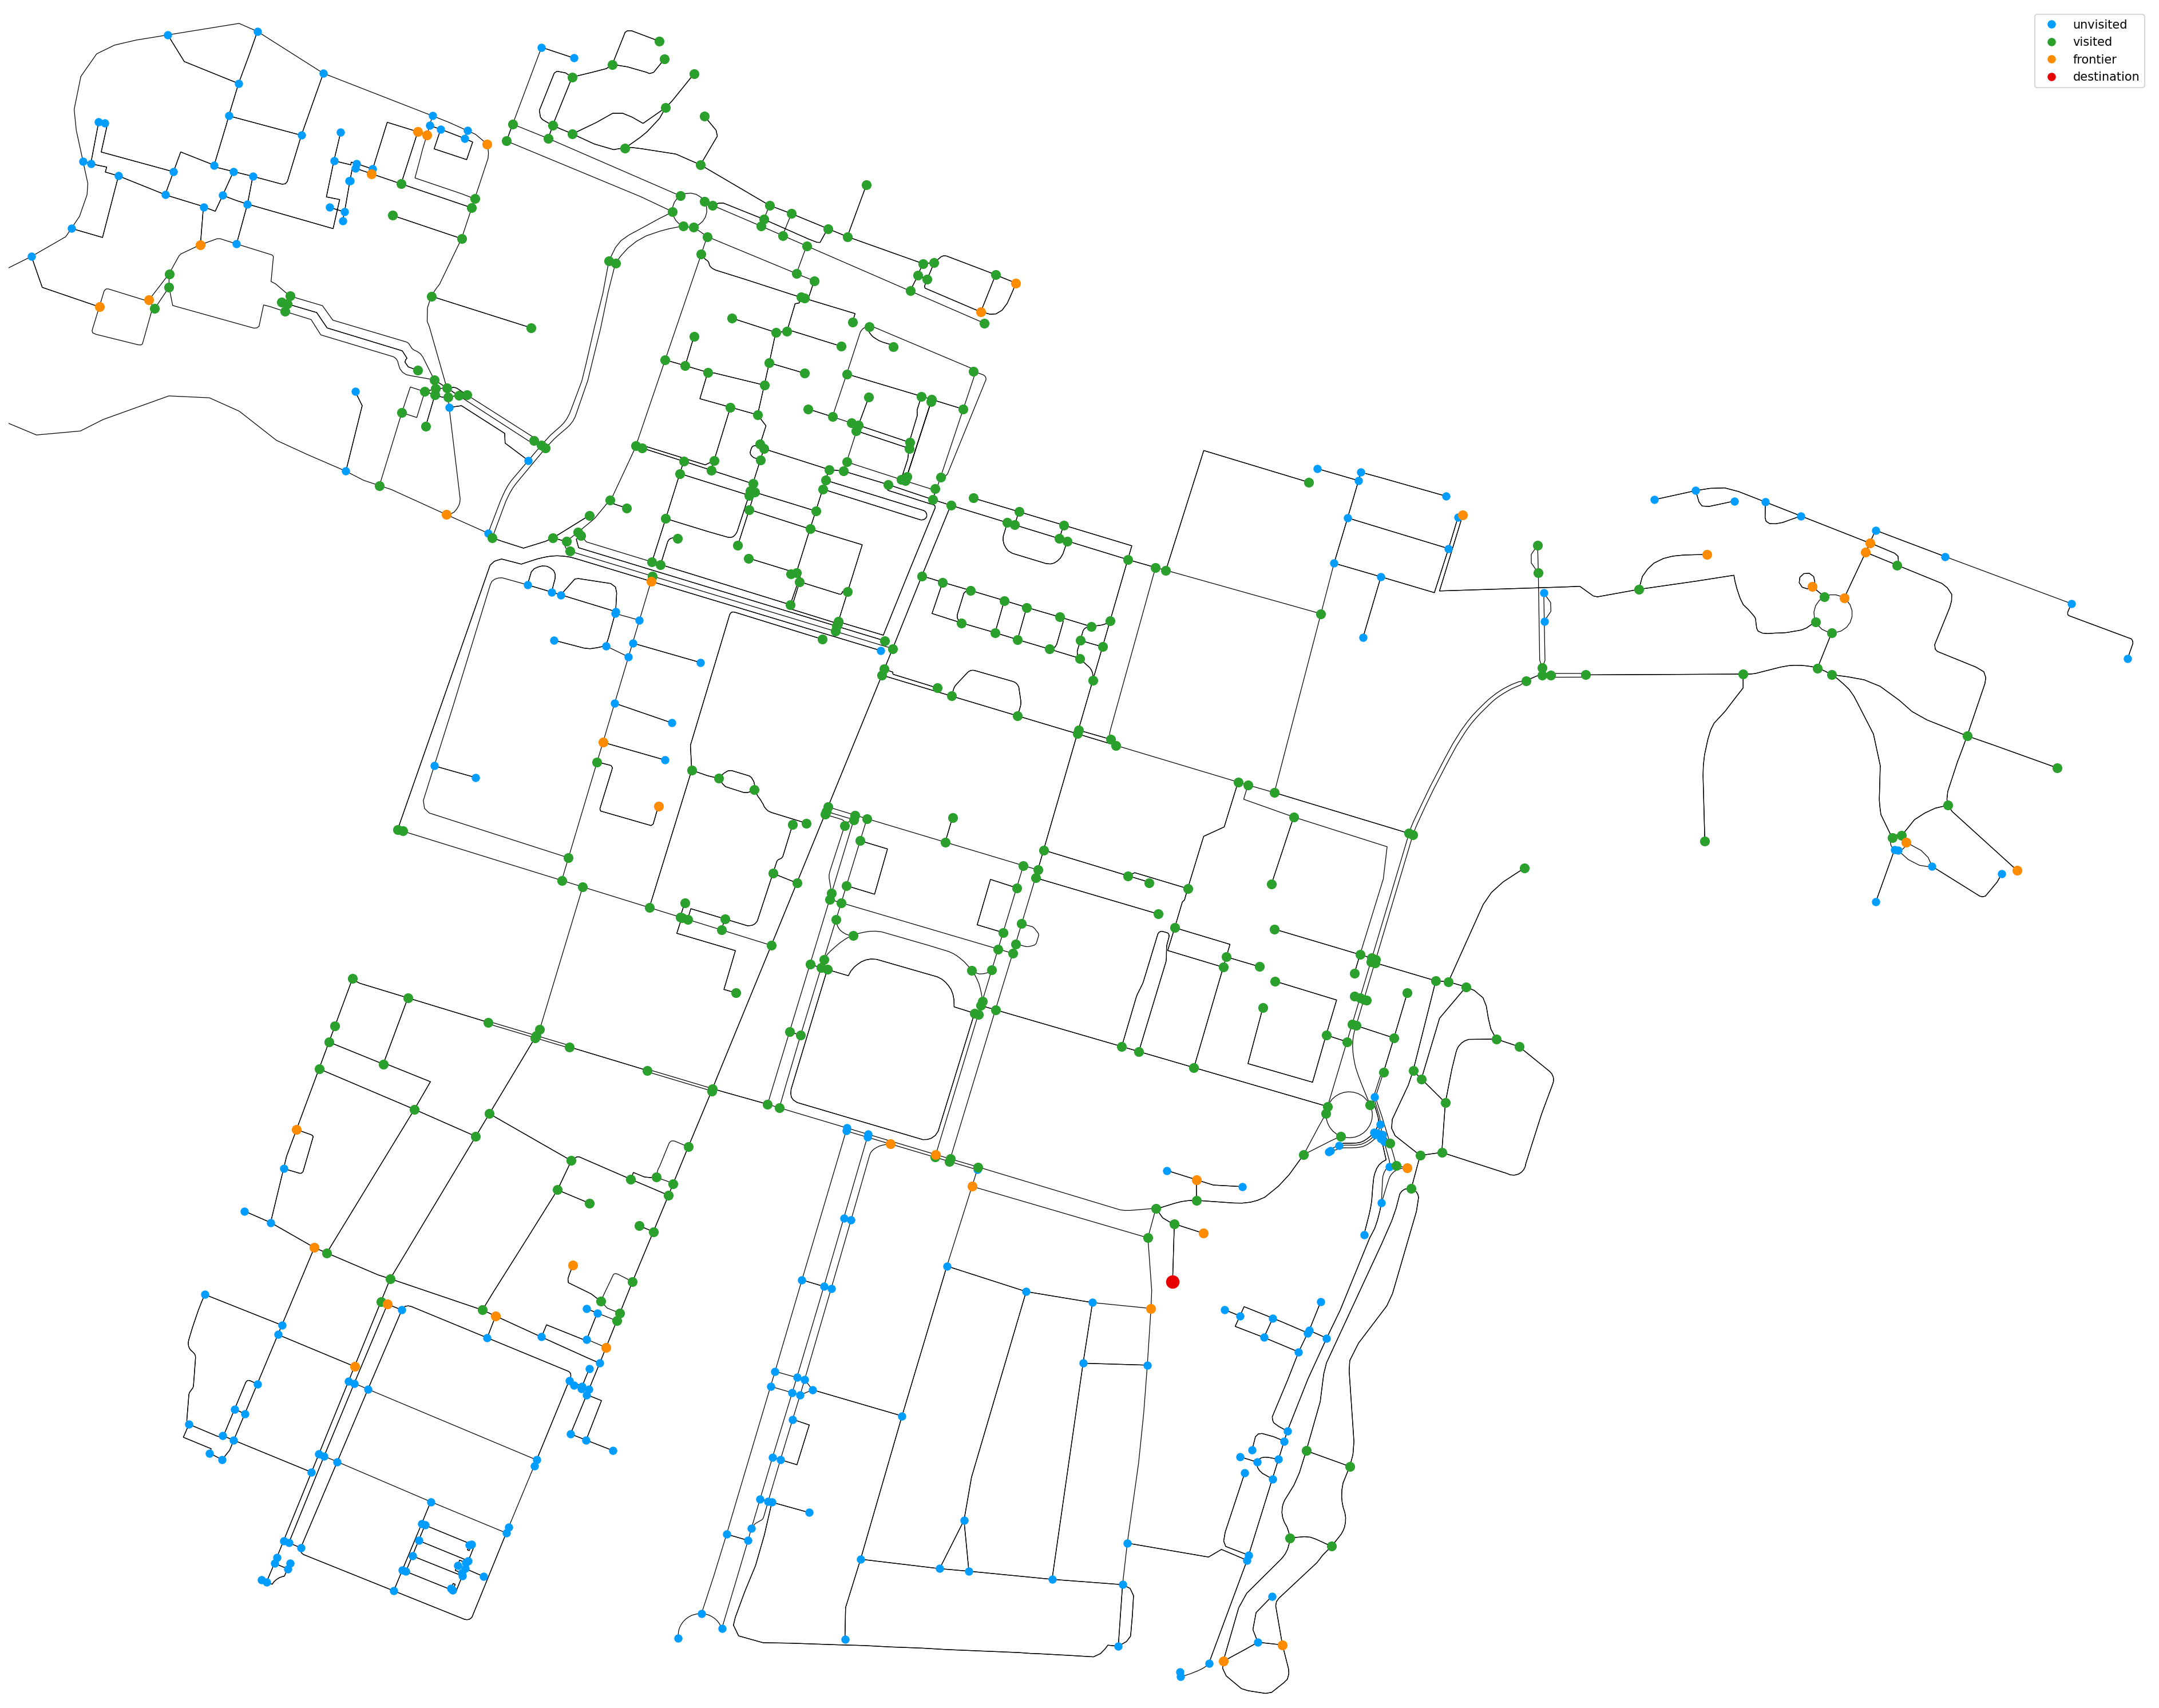

In [22]:
# This will show all the explored (green) and frontier (orange) nodes
# at the moment when your algorithm found the solution

clear_map(graph)
start_node.mark_graph_node_as_start(graph)
destination_node.mark_graph_node_as_destination(graph)
solution_node = breadth_first_search(graph, start_node, destination_node)
plot_graph(graph, fig_height=20, dpi=150, node_size=35)


In [23]:
# This will show you the real-time visualization of your algorithm
# when it explores nodes.

# Visualization is slow and we will not require you to show this cell.
# To get credit just show us the solution of the previous cell.

# This cell was made only for learning purposes.

#clear_map(graph)
#start_node.mark_graph_node_as_start(graph)
#destination_node.mark_graph_node_as_destination(graph)
#solution_node = breadth_first_search_interactive(graph, start_node, destination_node)


Now let's actually see the path that the algorithm found. We can do this now by taking
the solution node and tracking it back to root. The ```.solution()``` method returns
the sequence of map IDs that represent the path.


Path length (number of hops): 25


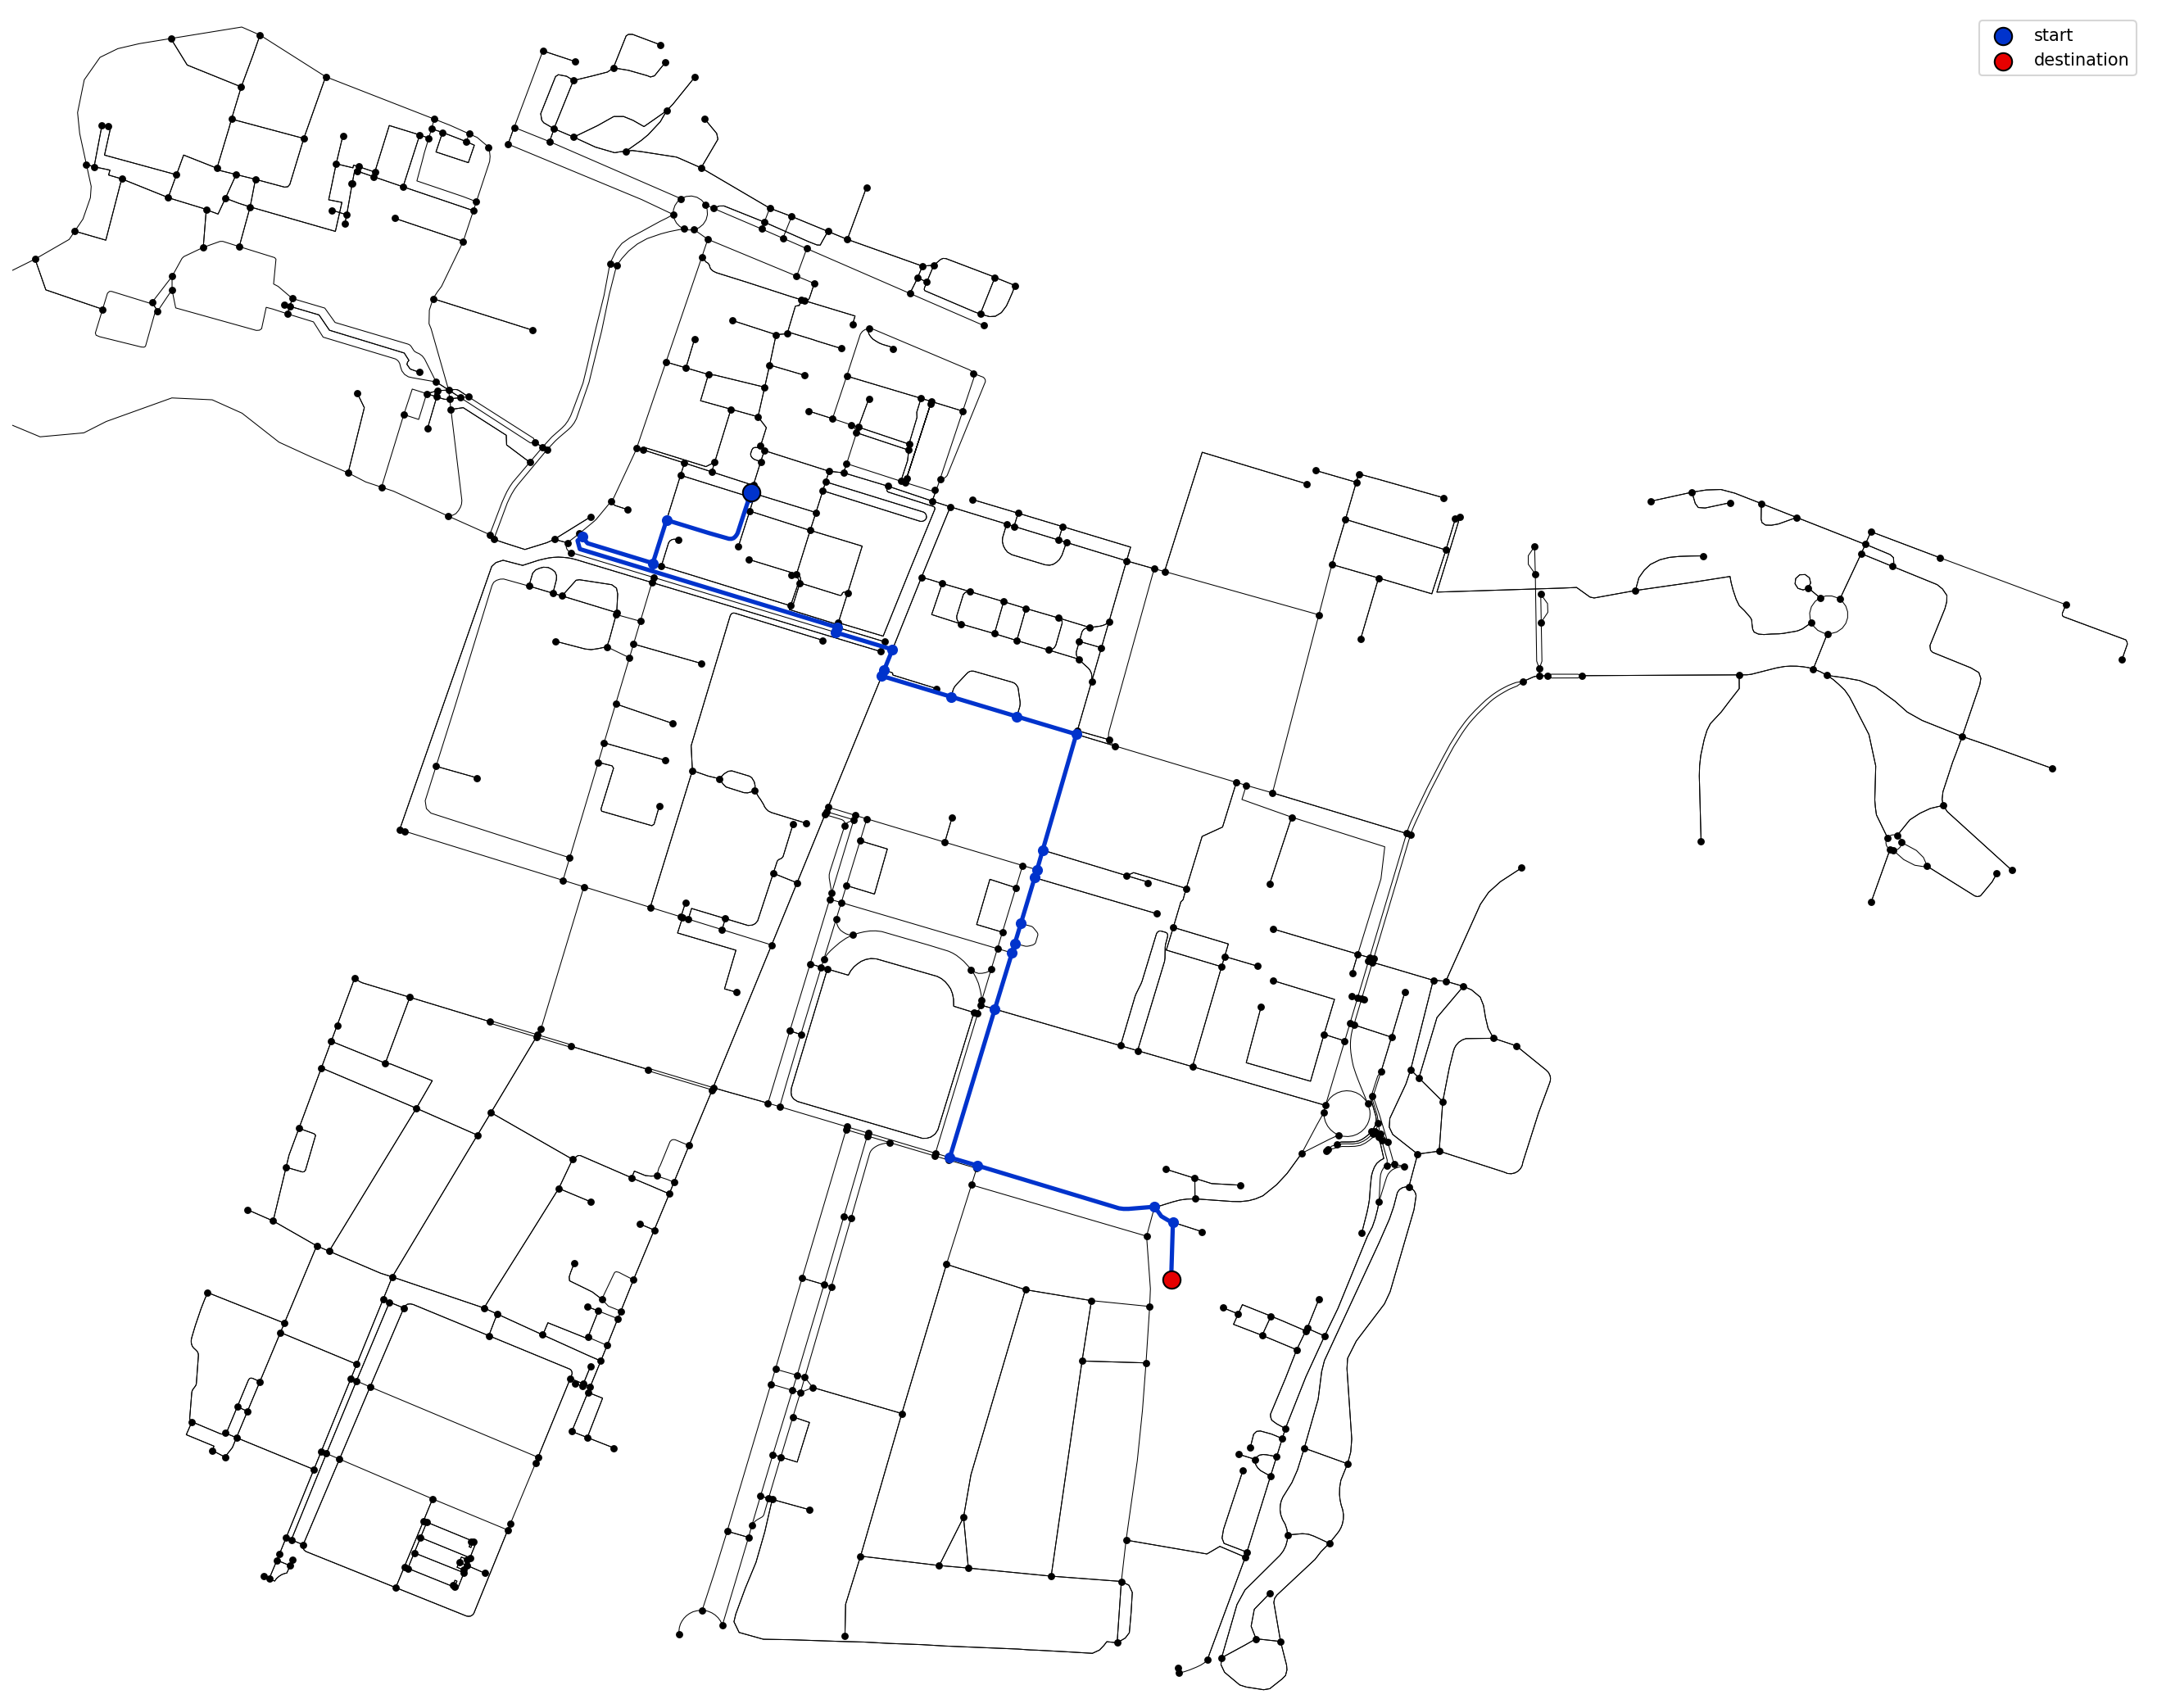

In [24]:
print("Path length (number of hops):", solution_node.path_cost)
plot_graph_route(graph, solution_node.solution())

<center> <h2> Second Algorithm </h2> </center>

BFS above finds a path with the *fewest number of hops*, but on a real street graph that's not
necessarily the *shortest* path in terms of actual distance, since some edges are much longer than
others. You can access the real-world distance (in meters) between two connected map nodes using:

```graph.edges[first_graph_element_id, second_graph_element_id, 0]['length']```

(the same value you saw printed for every edge in the `inspect_graph` output above.)

**Implement at least other search algorithm** (choose whichever you
like, but no starter code is provided for this part, you're building it from scratch using the same
`Node` / `expand` / `mark_graph_node_as_*` building blocks as BFS above). Here are some searching algorithms you can experiment with:

1. Depth-first search
2. Uniform-cost search
3. Depth-limited search
4. Iterative deepening search
5. A\* search

and many more...

Compare your second algorithm's path against the BFS path above. Do they find the same route?
If not, why not? Explain your findings in your report.


### **Please Read: Earlier, I accidentally made the integrated gemini generate the code without my knowledge since I am new to Colab and it was suddenly done, so I immediately erased it as u can see in the history - Alaric**

In [25]:
import heapq

def uniform_cost_search(graph, start_node, destination_node):
  frontier = []
  counter = 0
  heapq.heappush(frontier, (0, counter, start_node))
  start_node.mark_graph_node_as_frontier(graph)

  explored_set = set()
  best_cost = {start_node.state: 0}

  while frontier:
    cost, _, current_node = heapq.heappop(frontier)
    if current_node.state == destination_node.state:
      return current_node

    if current_node.state in explored_set:
      continue

    explored_set.add(current_node.state)
    current_node.mark_graph_node_as_visited(graph)

    for neighbor in current_node.expand(graph):
      edge_length = graph.edges[current_node.state, neighbor.state, 0]['length']
      neighbor.path_cost = current_node.path_cost + edge_length

      if neighbor.state in explored_set:
        continue
      if neighbor.state not in best_cost or neighbor.path_cost < best_cost[neighbor.state]:
        best_cost[neighbor.state] = neighbor.path_cost
        counter += 1
        heapq.heappush(frontier, (neighbor.path_cost, counter, neighbor))
        neighbor.mark_graph_node_as_frontier(graph)
  return None





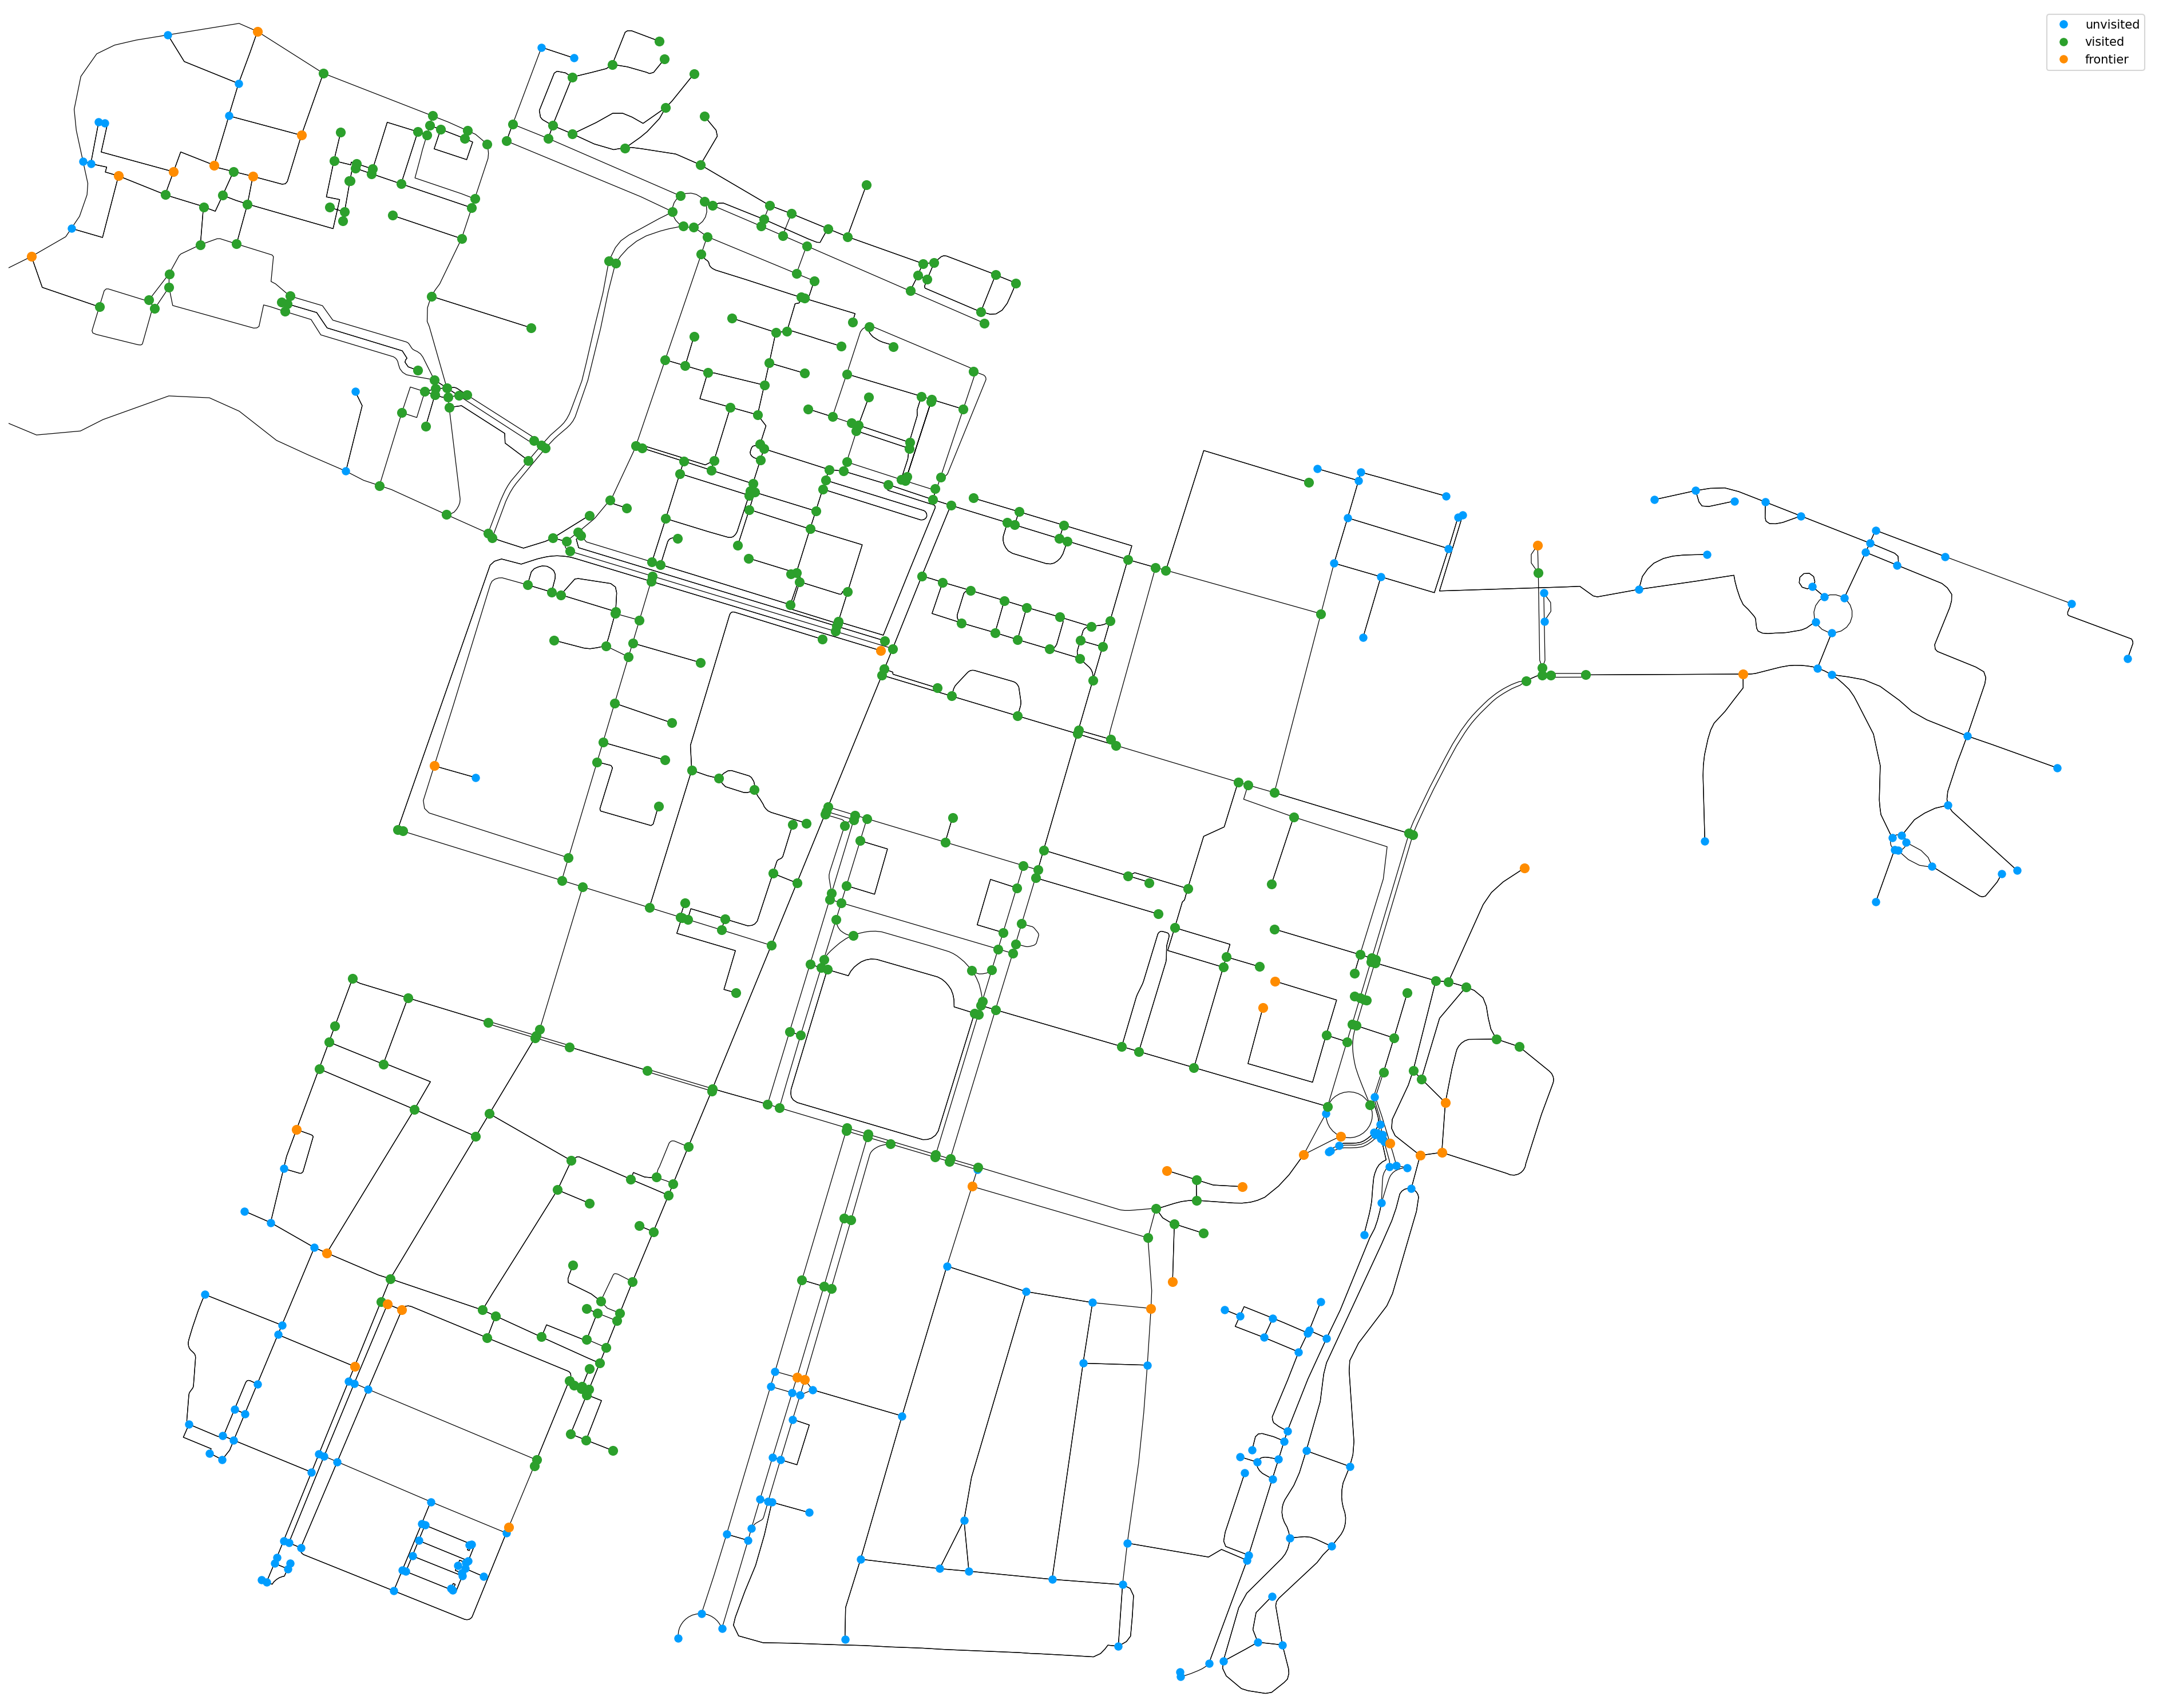

In [26]:
clear_map(graph)
start_node.mark_graph_node_as_start(graph)
destination_node.mark_graph_node_as_destination(graph)

ucs_solution_node = uniform_cost_search(graph, start_node, destination_node)
plot_graph(graph, fig_height=20, dpi=150, node_size=35)

Path length (total distance in meters): 1114.3683547181508


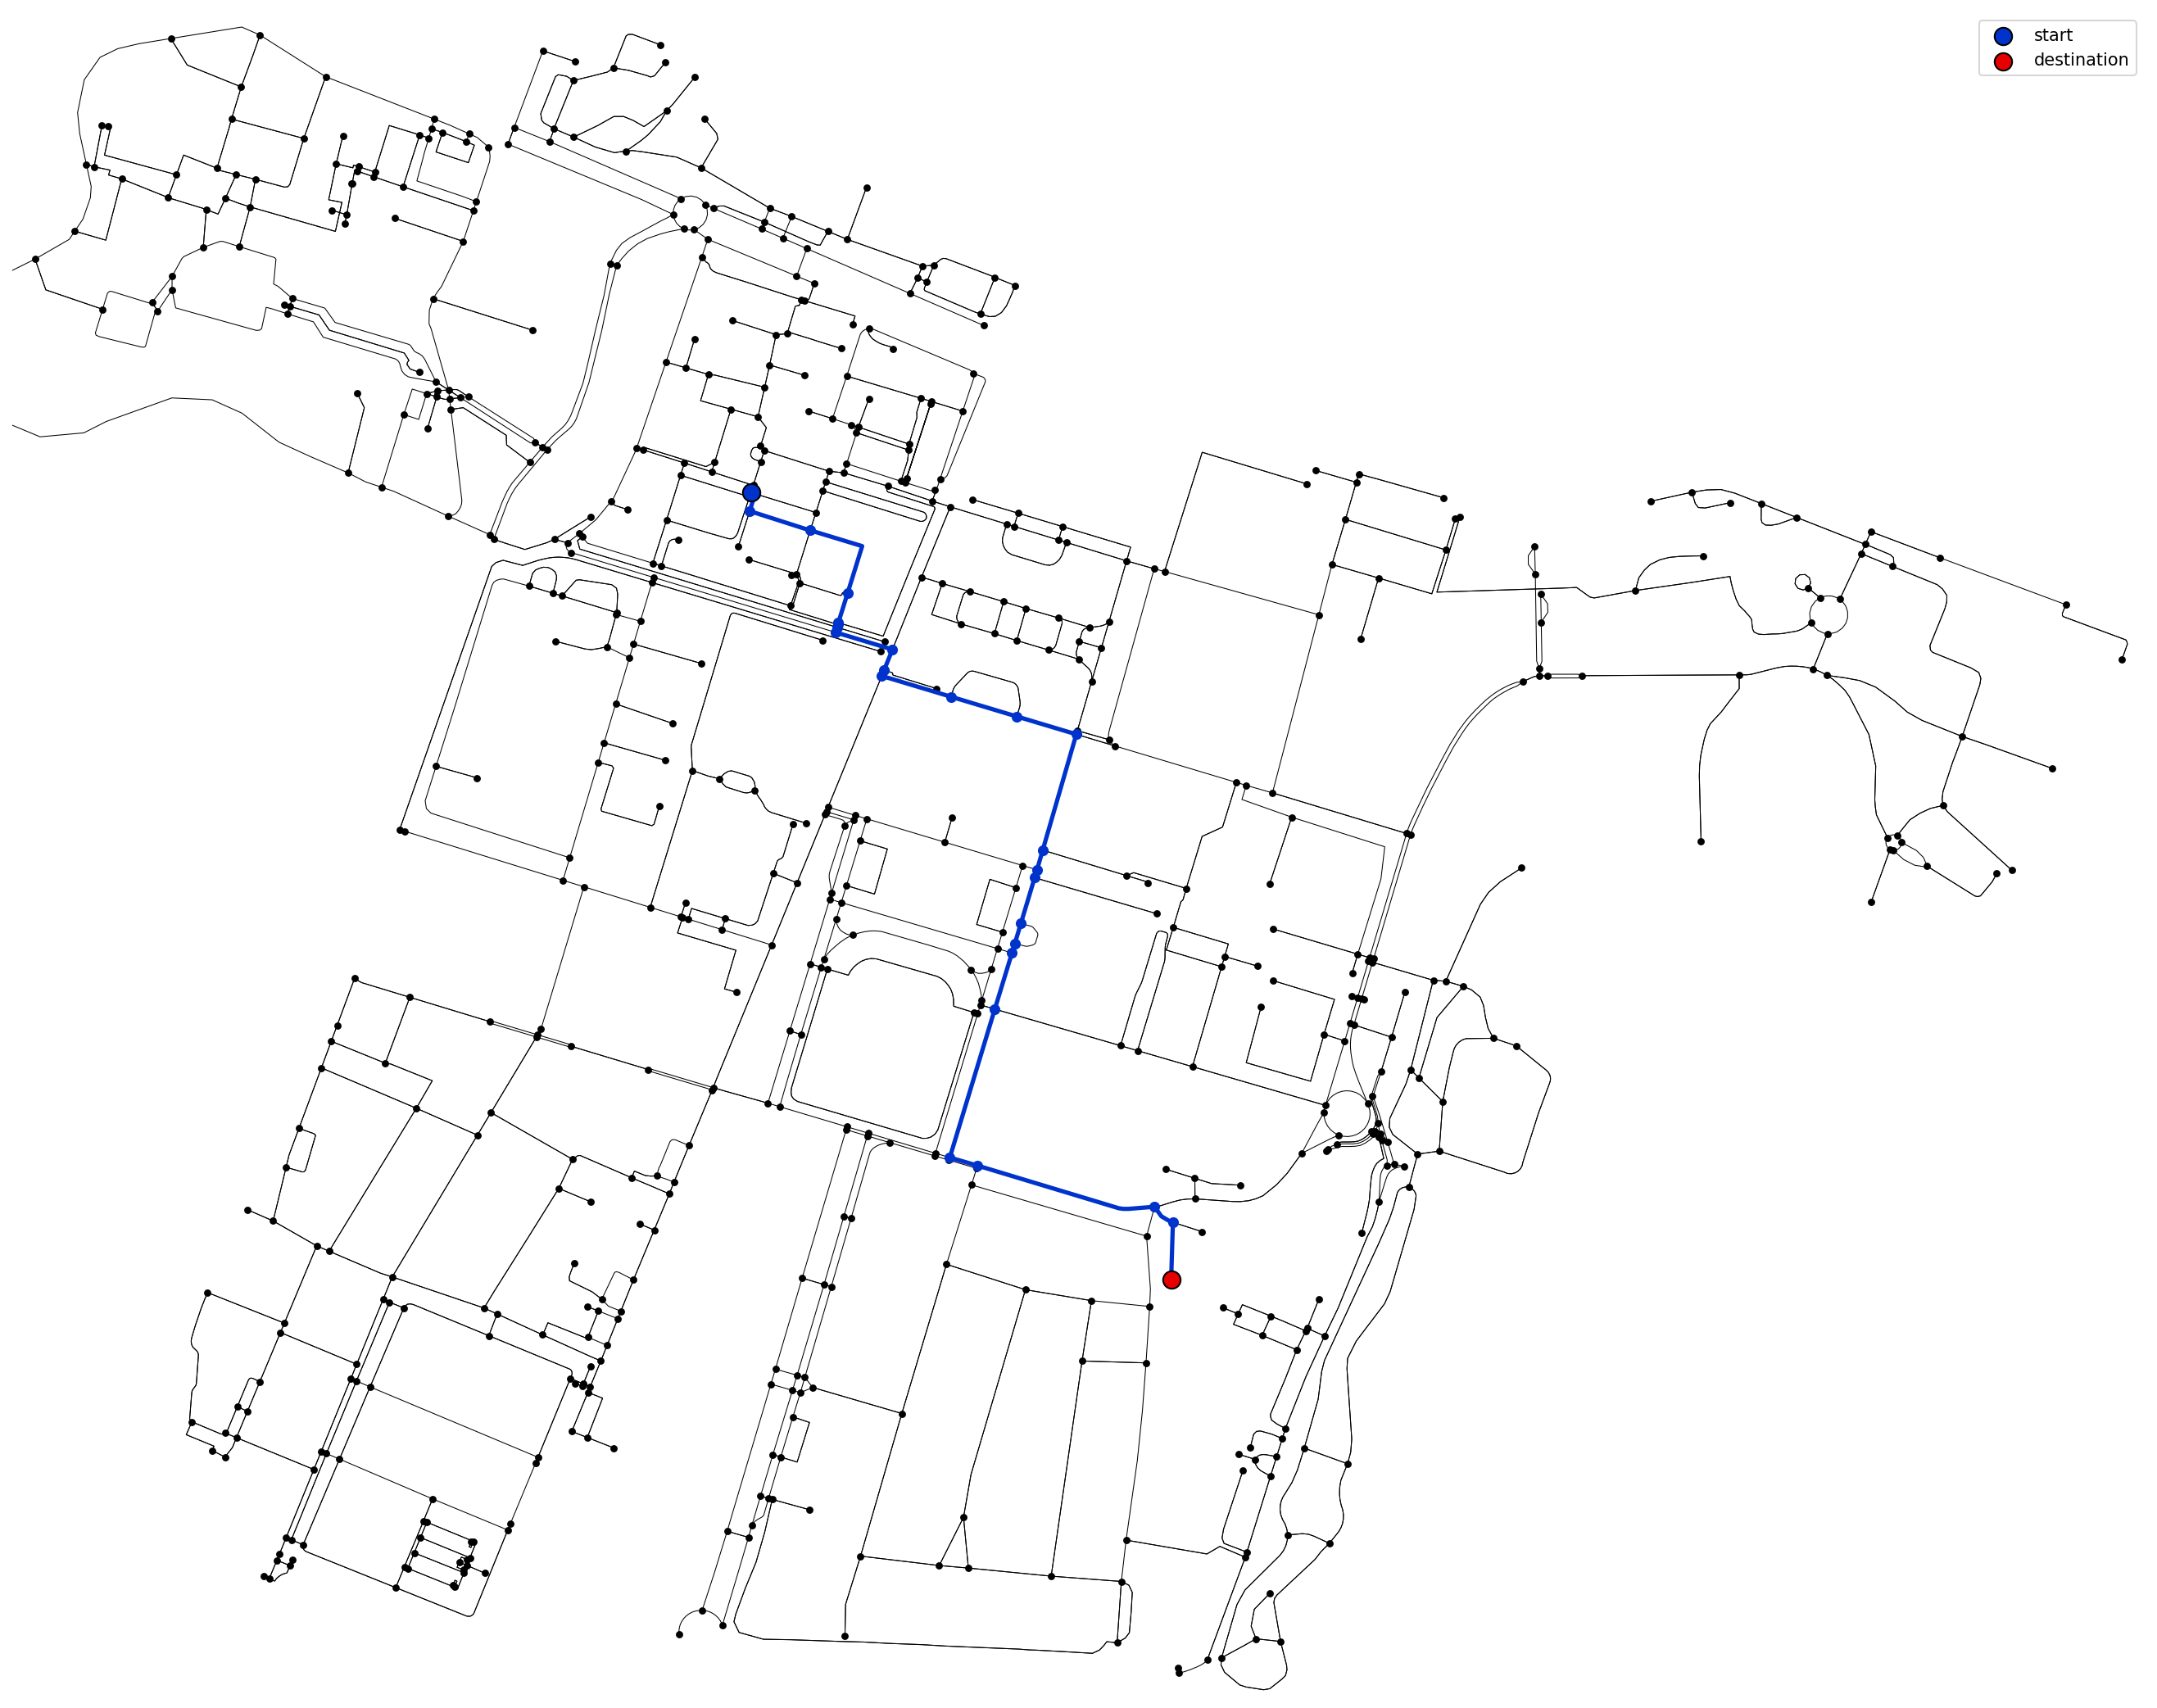

In [27]:
print("Path length (total distance in meters):", ucs_solution_node.path_cost)
plot_graph_route(graph, ucs_solution_node.solution())